<a href="https://colab.research.google.com/github/boniphacebenja78-lgtm/ai-course-lab0/blob/main/lab0_exercises_ipynb(exercise_6_7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'hours_studied': np.random.normal(15, 5, n_students),
    'exam_score': np.random.normal(75, 12, n_students)
}

df = pd.DataFrame(data)



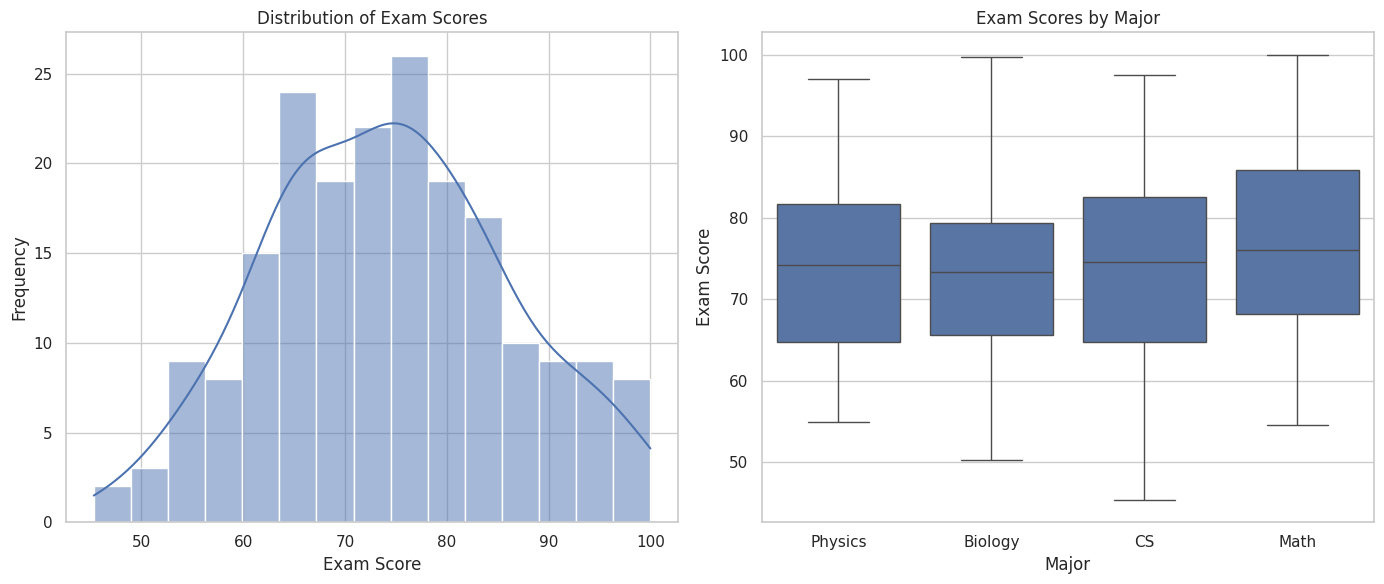

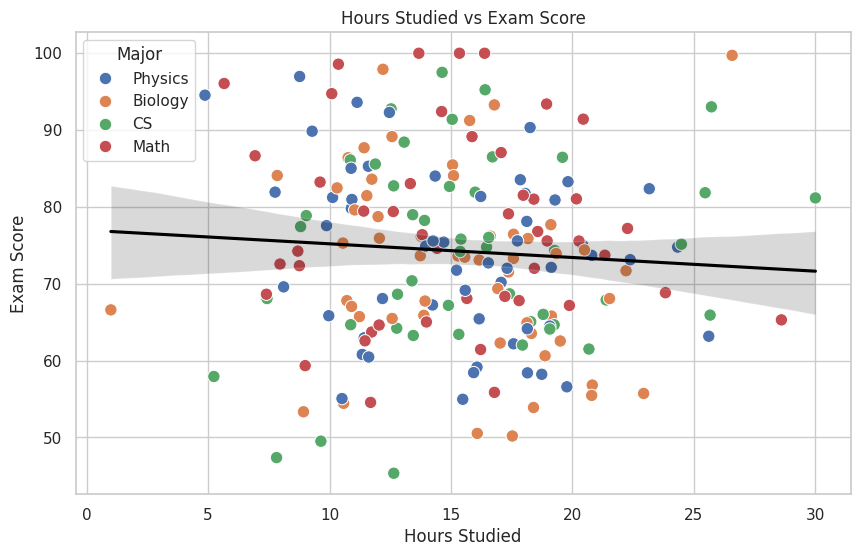

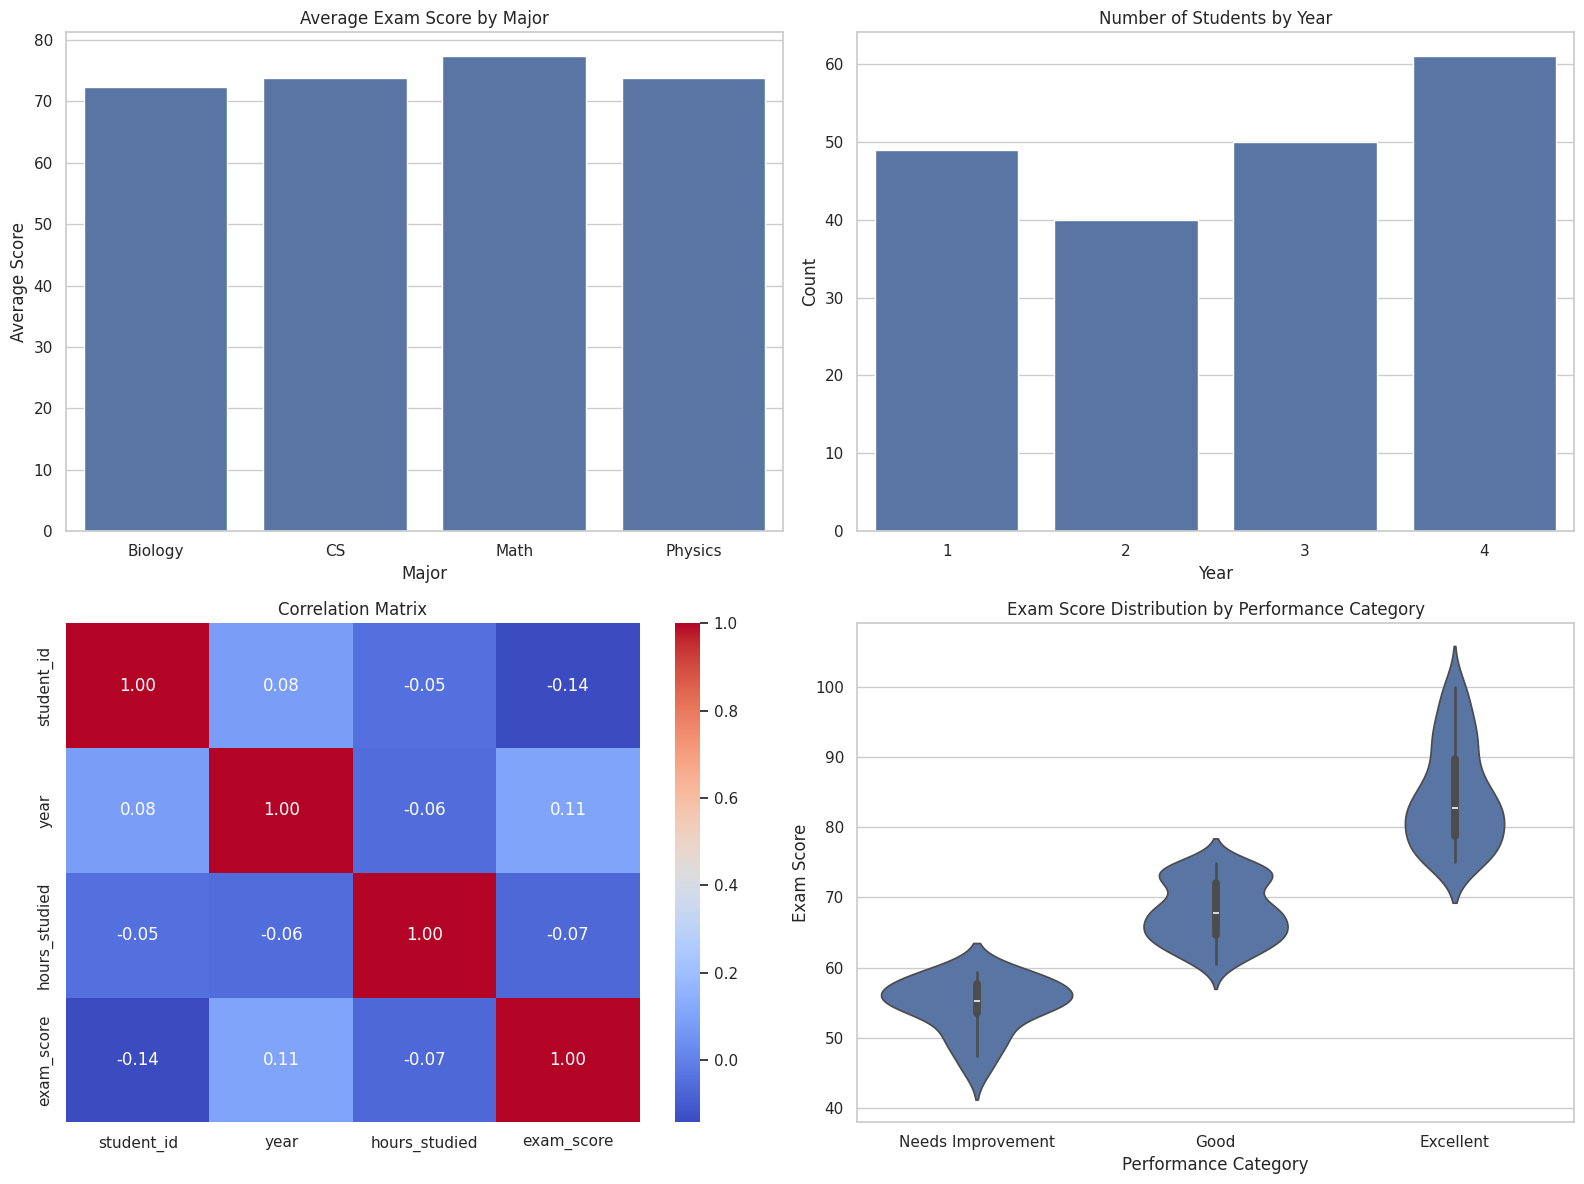

In [14]:

# Exercise 6: DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)
n_students = 200

df = pd.DataFrame({
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 30),
    'exam_score': np.random.normal(75, 12, n_students).clip(0, 100)
})

# Create performance categories
df['performance_category'] = pd.cut(
    df['exam_score'],
    bins=[0, 60, 75, 100],
    labels=['Needs Improvement', 'Good', 'Excellent']
)

sns.set_theme(style="whitegrid")


# TASK 1: Distribution Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE using seaborn libry
sns.histplot(
    df['exam_score'],
    bins=15,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Box Plot by Major using seaborn as sns
sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# TASK 2: Relationship Visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    s=80
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# TASK 3: Advanced Dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Exam Average Score by Major
avg_scores = df.groupby('major')['exam_score'].mean()

sns.barplot(
    x=avg_scores.index,
    y=avg_scores.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")

# 2. number of student by year.
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

# 3. Correlation Heatmap: correlation matix of numerical columns
numerical_columns = df.select_dtypes(include=np.number)

sns.heatmap(
    numerical_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Correlation Matrix")

# 4. Violin Plot: exams score distribution by performance category
sns.violinplot(
    data=df,
    x='performance_category',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title("Exam Score Distribution by Performance Category")
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

/tmp/ipykernel_28468/105189890.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = customers.groupby('age_group').agg(


CUSTOMER SUMMARY BY AGE GROUP
           Number_of_Customers  Average_Income  Average_CLV      Total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683


TOP 10% CUSTOMERS BY CLV
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   
60   25  66508.326980          

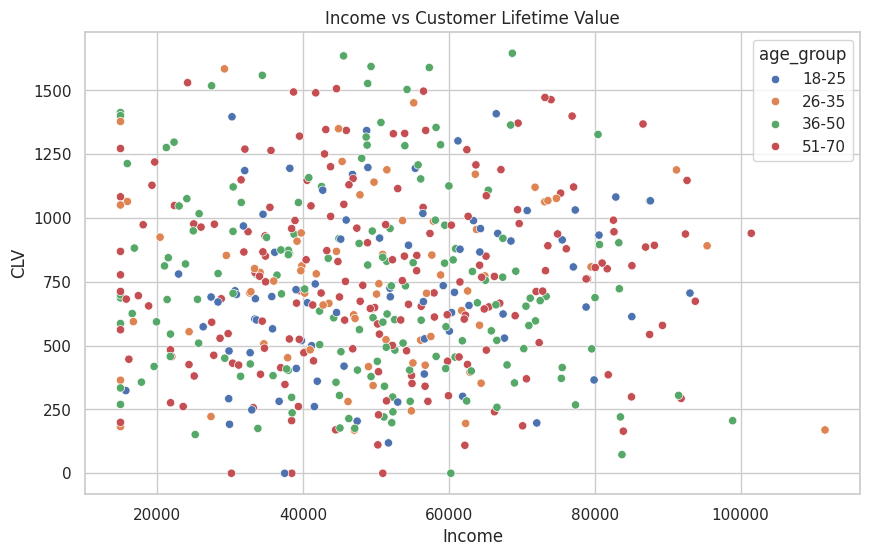

/tmp/ipykernel_28468/105189890.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


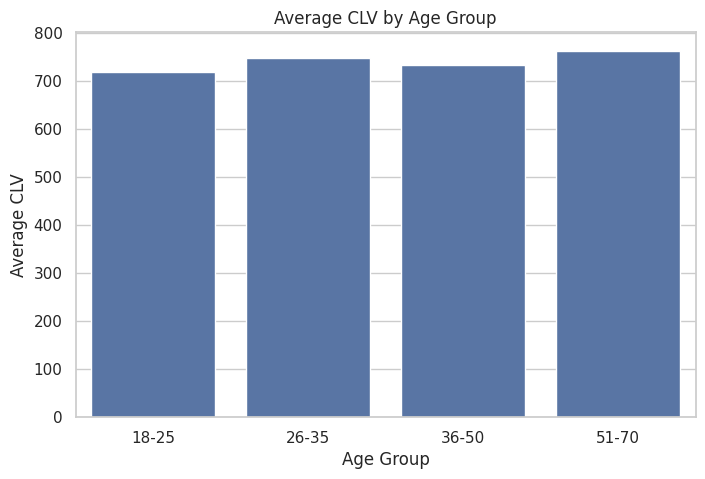

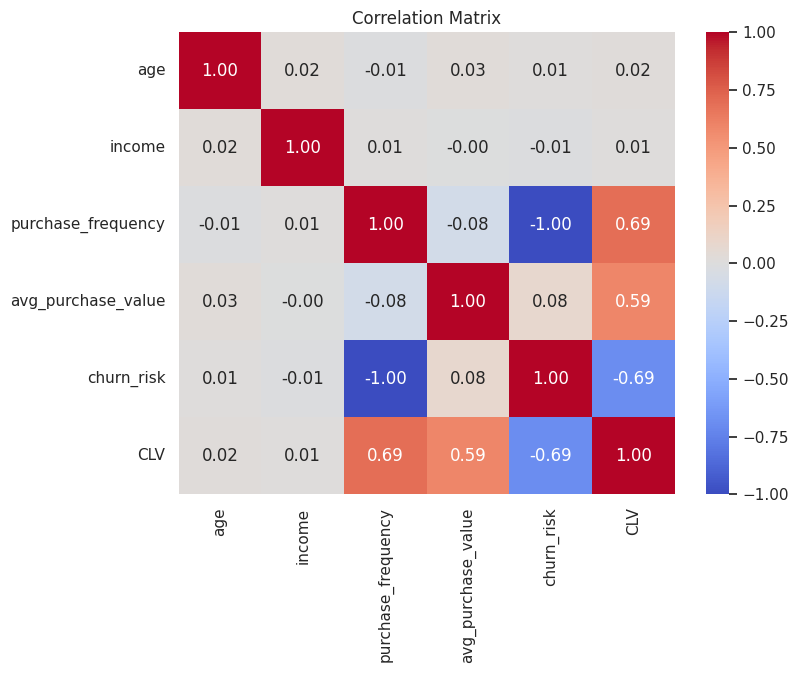

In [19]:
# EXCERCISE 7: DATA INTEGRATION CHALLENGE

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DATA FROM E-commerce company
# Generate synthetic customer data

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculating customer lifetime value(CLV)

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Create Age Groups
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

# FOR EACH AGE GROUP CALCULATE
summary = customers.groupby('age_group').agg(
    Number_of_Customers=('age', 'count'),
    Average_Income=('income', 'mean'),
    Average_CLV=('CLV', 'mean'),
    Total_CLV=('CLV', 'sum')
)

print("=" * 60)
print("CUSTOMER SUMMARY BY AGE GROUP")
print("=" * 60)
print(summary)

# Top 10% Customers by CLV
clv_threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= clv_threshold
]
print("\n")
print("=" * 60)
print("TOP 10% CUSTOMERS BY CLV")
print("=" * 60)
print(top_customers.head(10))

# Visualization 1: Income vs CLV Scatter Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.show()

# Visualization 2: Average CLV by Age Group
plt.figure(figsize=(8, 5))

avg_clv = customers.groupby('age_group')['CLV'].mean()

sns.barplot(
    x=avg_clv.index,
    y=avg_clv.values
)
plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.show()

# Visualization 3: Correlation Heatmap
plt.figure(figsize=(8, 6))

numeric_columns = customers.select_dtypes(include=np.number)

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()